In [1]:
import astropy.table as at
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import thejoker as tj
import thejoker.units as xu
from astropy.time import Time
from astropy.visualization.units import quantity_support
import pymc as pm


%matplotlib inline

In [2]:
# --- 0) Setup
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time
from astropy.table import Table

from thejoker import RVData, TheJoker
from thejoker.prior import JokerPrior
# (Optional) for MCMC refinement if multi-modal/posterior is broad:
# from thejoker.emcee import sample_posterior


In [3]:
path = '/mnt/c/Users/Jonah/Astro/Stars/DATA/Unified_Code_Fit/per_star/'
star = 'FRBoo'

outdir_fit = 'fit_diagrams_v4'
outdir_Pe = 'Pe_diagrams_v4'

import os
os.makedirs(outdir_fit, exist_ok=True)  # create folder if it doesn't already exist
os.makedirs(outdir_Pe, exist_ok=True) 


fullpath = f"{path}{star}/{star}_data.txt"  # <-- folder/star/star_data.txt
nan = np.nan
with open(fullpath, "r") as f:
    txt = f.read()
    data = np.array(eval("[" + txt.strip().rstrip(",") + "]"))




bjd = data[:,0]
rv  = data[:,1]                   # assumed km/s
err = 0.5*(data[:,2] + data[:,3]) # average hi/lo

# --- 1) Package the data for The Joker
t = Time(bjd, format="jd")        # JD/BJD times
tbl = Table()
tbl["t"]       = t
tbl["rv"]      = rv * (u.km/u.s)
tbl["rv_err"]  = err * (u.km/u.s)

data_joker = RVData(
    t=tbl["t"],                # astropy Time
    rv=tbl["rv"],              # km/s with units
    rv_err=tbl["rv_err"],      # km/s with units
    #instrument=tbl["instrument"]  # array of strings
)

print(data)

[[ 2.45898073e+06 -2.33240000e+01  8.00000000e-02  7.60000000e-02
              nan             nan             nan]
 [ 2.45904372e+06 -2.47440000e+01  7.40000000e-02  7.90000000e-02
              nan             nan             nan]
 [ 2.45904466e+06 -2.44480000e+01  9.10000000e-02  9.10000000e-02
              nan             nan             nan]
 [ 2.45924599e+06 -1.81460000e+01  8.10000000e-02  7.50000000e-02
              nan             nan             nan]
 [ 2.45930378e+06 -1.81090000e+01  1.63000000e-01  1.38000000e-01
              nan             nan             nan]
 [ 2.45930379e+06 -1.83500000e+01  9.10000000e-02  8.20000000e-02
              nan             nan             nan]
 [ 2.45930586e+06 -1.81720000e+01  9.70000000e-02  1.02000000e-01
              nan             nan             nan]
 [ 2.45932782e+06 -1.83230000e+01  1.02000000e-01  8.30000000e-02
              nan             nan             nan]
 [ 2.45933879e+06 -1.83370000e+01  9.40000000e-02  9.30000000e-0

<Axes: xlabel='time [BMJD]', ylabel='RV [$\\mathrm{km\\,s^{-1}}$]'>

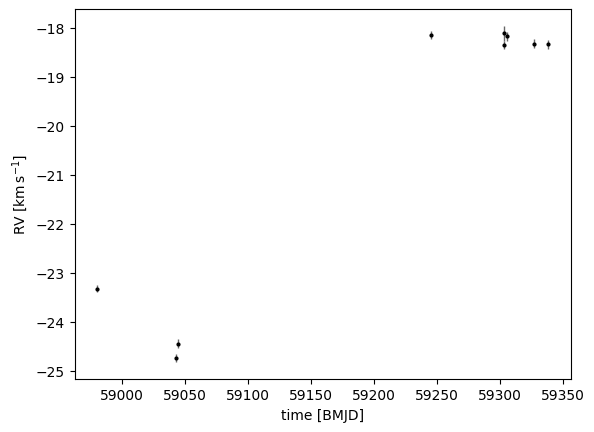

In [4]:
data_joker.plot(markersize=2)

In [64]:

prior = tj.JokerPrior.default(
    P_min= 1100 * u.day,
    P_max=1200 * u.day,
    sigma_K0=12 * u.km / u.s,
    sigma_v=10 * u.km / u.s,

    
)
prior_samples = prior.sample(size = 5_000_000, return_logprobs = True)
print('Done')

/home/jonah/.venvs/astro/lib/python3.12/site-packages/pymc/logprob/abstract.py:236: UserWarning: ValuedVar should not be present in the final graph!
  warnings.warn("ValuedVar should not be present in the final graph!")


Done


In [65]:
'''
with pm.Model() as model:
    P = xu.with_unit( pm.TruncatedNormal("P", mu=30, sigma=30, lower=2), u.day)

    
    prior = tj.JokerPrior.default(
        sigma_K0=200 * u.km / u.s, 
        sigma_v=10 * u.km / u.s, 
        pars={"P": P}
    )

prior_samples = prior.sample(size=500000)

#plt.hist(prior_samples["P"].to_value(u.day), bins=50)
#plt.xlabel("$P$ [day]")
'''

'\nwith pm.Model() as model:\n    P = xu.with_unit( pm.TruncatedNormal("P", mu=30, sigma=30, lower=2), u.day)\n\n\n    prior = tj.JokerPrior.default(\n        sigma_K0=200 * u.km / u.s, \n        sigma_v=10 * u.km / u.s, \n        pars={"P": P}\n    )\n\nprior_samples = prior.sample(size=500000)\n\n#plt.hist(prior_samples["P"].to_value(u.day), bins=50)\n#plt.xlabel("$P$ [day]")\n'

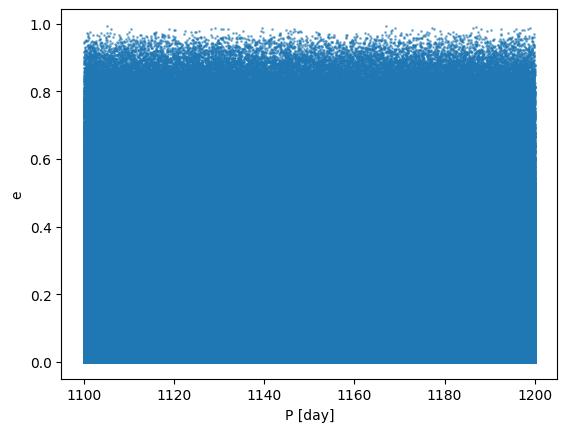

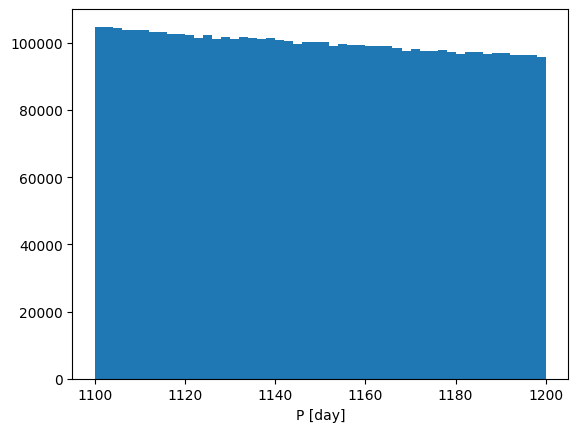

In [66]:


plt.scatter(prior_samples["P"], prior_samples["e"], s = 1, alpha = 0.5)
plt.xlabel('P [day]')
plt.ylabel('e')



plt.show()
plt.hist(prior_samples["P"], bins = 50)
plt.xlabel('P [day]')
plt.show()





In [67]:
joker = tj.TheJoker(prior)
joker_samples = joker.iterative_rejection_sample(data_joker, prior_samples, return_logprobs = True, n_requested_samples = 50)

print("Accepted:", len(joker_samples))

Accepted: 29


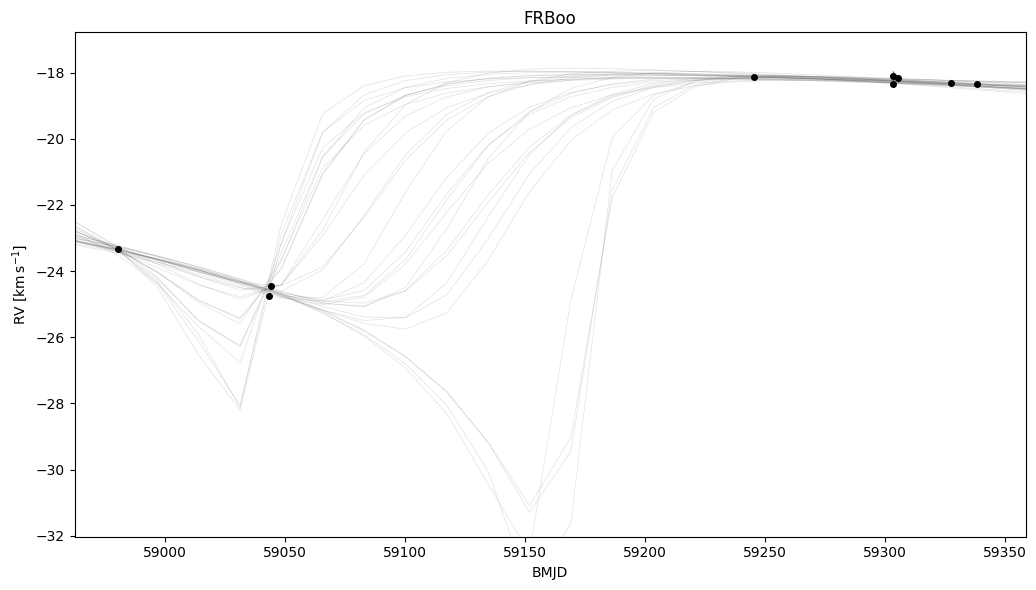

In [68]:
fig, ax = plt.subplots(figsize=(10.5, 6))
_ = tj.plot_rv_curves(joker_samples, data=data_joker)
plt.title(f'{star}')
plt.tight_layout()
plt.savefig(f'{outdir_fit}/{star}_fit.png', dpi = 300)
plt.show()


Median P:	1146.7202 d
Mean e:  	0.7216



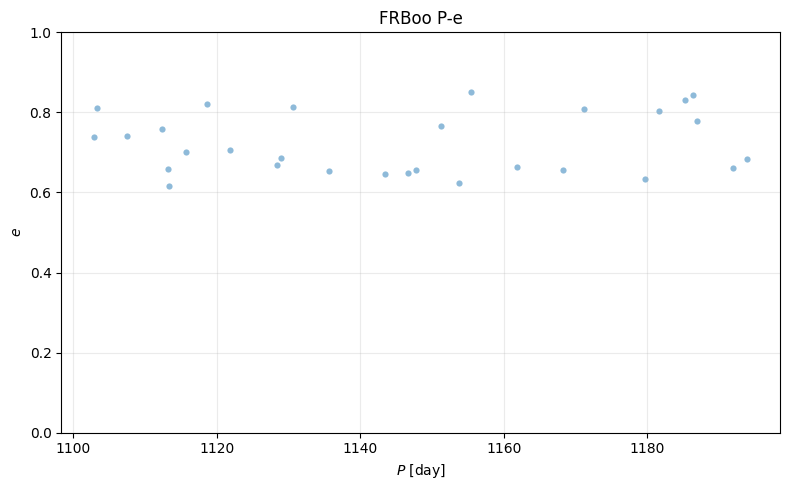

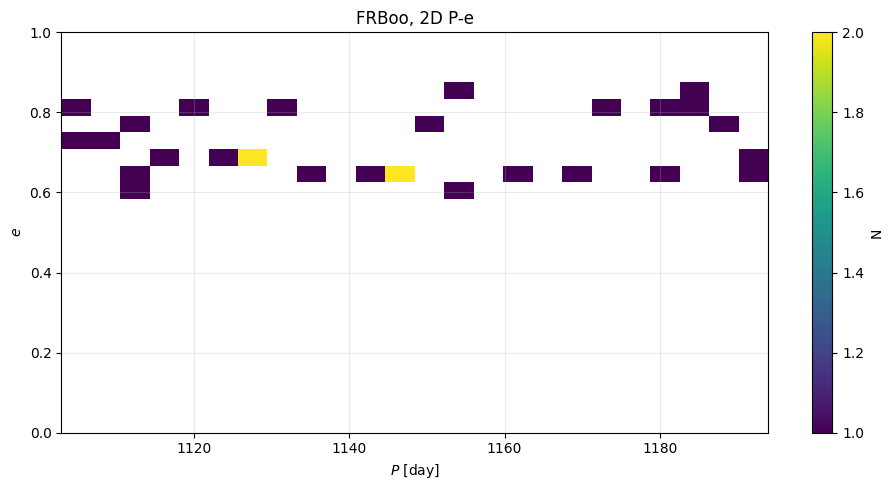

In [74]:

Pmed = np.median(joker_samples["P"])
emean = np.mean(joker_samples["e"])

print(f"""
Median P:\t{Pmed:.4f}
Mean e:  \t{emean:.4f}
""")



fig, ax = plt.subplots(1, 1, figsize=(8, 5))

with quantity_support():
    ax.scatter(joker_samples["P"], joker_samples["e"], s=20, lw=0, alpha=0.5, label = f'{joker_samples["P"]}, {joker_samples["e"]}')

#ax.scatter(np.median(joker_samples["P"]), np.mean(joker_samples["e"]), s = 20, color = 'r', alpha = 0.5,
#         label = f'P: {Pmed:.3f}, e: {emean:.3f}')

#ax.set_xscale("log")
#ax.set_xlim(1, 100)
ax.set_ylim(0, 1)

ax.set_xlabel("$P$ [day]")
ax.set_ylabel("$e$")
ax.grid(True, alpha = 0.25)
plt.title(f'{star} P-e')
#plt.legend()
plt.tight_layout()
plt.savefig(f'{outdir_Pe}/{star}_Pe.png', dpi = 300)
plt.show()


'''
# Histogram of periods
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
with quantity_support():
    ax.hist(joker_samples["P"], bins=30, alpha=0.7)

#ax.set_xscale("log")  # optional if you want a log-scale period axis
ax.set_xlabel("$P$ [day]")
ax.set_ylabel("Count")
plt.title(f"{star} Period Distribution")
plt.grid(alpha=0.25)
ax.set_xlim(1, 1e2)
#plt.savefig(f"{star}_Phist.png", dpi=100)
plt.tight_layout()
plt.show()
'''



# Convert to plain arrays
P = joker_samples["P"].to_value(u.day)   # Period in days (floats)
e = np.asarray(joker_samples["e"])       # Eccentricity (dimensionless)

# Define bin edges — linear, not log
xbins = np.linspace(np.min(P), np.max(P), 25)   # 0 to 100 days
ybins = np.linspace(0, 1, 25)     # 0 to 1 eccentricity

# Create 2D histogram
fig, ax = plt.subplots(figsize=(9.65, 5))
h = ax.hist2d(P, e, bins=(xbins, ybins), cmap="viridis", cmin=1)

# Add colorbar for density
cb = fig.colorbar(h[3], ax=ax)
cb.set_label("N")

# Axis limits (linear)
#ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("$P$ [day]")
ax.set_ylabel("$e$")
ax.set_title(f"{star}, 2D P-e")
ax.grid(alpha=0.25)

plt.tight_layout()
#plt.savefig(f"{star}_Pe_hist2d_linear.png", dpi=100)
plt.show()

In [75]:
joker_samples.tbl

P,e,omega,M0,s,K,v0,ln_likelihood,ln_prior
d,,rad,rad,km / s,km / s,km / s,,
float64,float64,float64,float64,float64,float64,float64,float64,float64
1153.764826302894,0.6226588363032176,-2.0305565890396116,0.7754063396844878,0.0,3.4196801550657128,-20.61603963109757,-7.58739053686792,-1152.3880129541712
1107.465238976647,0.739943305810061,-2.3641396718416603,0.3702839955579563,0.0,3.683253428541001,-19.80004822704489,-3.02603336967776,-1106.8670456999228
1192.0025475027298,0.6613151896283257,1.0576720338751984,0.6565866708486917,0.0,-3.408724370084082,-20.433083646227065,-5.802735711386149,-1190.853146998448
1193.9583523802373,0.6834960901178396,-2.0297868046600196,0.7057931466996619,0.0,3.565310350957837,-20.448427326348348,-6.959874225536751,-1192.950840258863
1186.9001144398133,0.7794281038127562,-2.504427189250183,0.3096162536682799,0.0,4.117342133133894,-19.623067166338824,-2.696572975435397,-1186.6431276176236
1146.7201702378356,0.6478472703924694,-2.1495988038874265,0.6608164737565533,0.0,3.338769319201367,-20.35065427485549,-5.771968854857837,-1145.4888732074837
1161.797673115648,0.662846178859394,1.0401397059056545,0.7756613163927853,0.0,-3.718431441194814,-20.567265618603937,-5.596947171831289,-1160.657777365164
1130.6908232142168,0.8135644622040169,0.8604455921164422,1.0501245580473266,0.0,-6.816481019448034,-21.34520181406162,-7.209061601663611,-1130.7808578719648


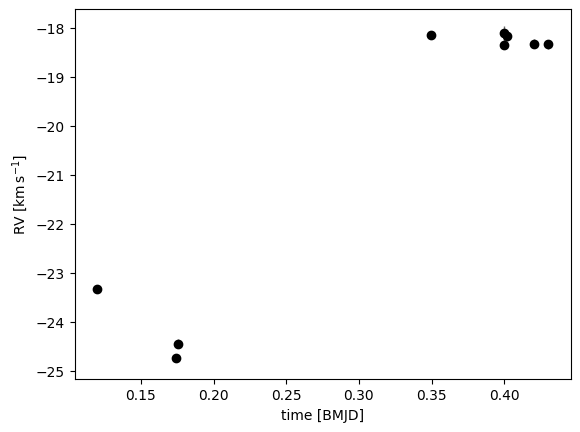

In [76]:
_ = data_joker.plot(phase_fold_period=joker_samples[0]["P"])

In [77]:
'''
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
_ = tj.plot_rv_curves(
    joker_samples,
    data=data,
    plot_kwargs=dict(color="tab:blue"),
    data_plot_kwargs=dict(color="tab:red"),
    relative_to_t_ref=True,
    ax=ax,
)
ax.set_xlabel(f"BMJD$ - {data.t.tcb.mjd.min():.3f}$")
'''

'\nfig, ax = plt.subplots(1, 1, figsize=(8, 4))\n_ = tj.plot_rv_curves(\n    joker_samples,\n    data=data,\n    plot_kwargs=dict(color="tab:blue"),\n    data_plot_kwargs=dict(color="tab:red"),\n    relative_to_t_ref=True,\n    ax=ax,\n)\nax.set_xlabel(f"BMJD$ - {data.t.tcb.mjd.min():.3f}$")\n'

In [78]:
# Sort highest-likelihood first
sorted_tbl = joker_samples.tbl[np.argsort(joker_samples.tbl['ln_likelihood'])[::-1]]

# Extract the P values (periods)
sorted_tbl


P,e,omega,M0,s,K,v0,ln_likelihood,ln_prior
d,,rad,rad,km / s,km / s,km / s,,
float64,float64,float64,float64,float64,float64,float64,float64,float64
1185.2381098072792,0.8299606487235741,0.5969380449905001,0.2990075071336269,0.0,-4.969448727762223,-19.696320158083456,-2.0139360433871936,-1185.5176711983092
1103.3191062435487,0.8109291693223628,-2.646551416318214,0.30722085606757366,0.0,5.084178858723666,-19.618693535010575,-2.112692346469407,-1103.3802159583927
1186.3296271605361,0.8422864733976229,0.6806134229227497,0.30838984008800074,0.0,-5.098871323355372,-19.711731582567626,-2.6407693889407096,-1186.7639059602564
1186.9001144398133,0.7794281038127562,-2.504427189250183,0.3096162536682799,0.0,4.117342133133894,-19.623067166338824,-2.696572975435397,-1186.6431276176236
1112.316873895582,0.7579615236906883,0.7976164658101469,0.3629419435046573,0.0,-3.8010716515990515,-19.78164695312008,-2.821768631458269,-1111.8676404723517
1107.465238976647,0.739943305810061,-2.3641396718416603,0.3702839955579563,0.0,3.683253428541001,-19.80004822704489,-3.02603336967776,-1106.8670456999228
1102.8965931569392,0.738517084816673,0.7755411114854966,0.37250649635920885,0.0,-3.704552490462059,-19.79108578631752,-3.028707973637133,-1102.2870406290324
1151.269658083394,0.7668024302891913,0.560186767521403,0.31258597809950334,0.0,-4.079611077660349,-19.588363062214892,-3.0328695078495644,-1150.8975046695678


In [79]:
from astropy.io import ascii
import os

star_name = star   # or whatever variable holds the current star name
outdir = "orbital_params"
os.makedirs(outdir, exist_ok=True)

outfile = os.path.join(outdir, f"{star_name}_orb_params.txt")

with open(outfile, "w") as f:
    f.write(f"# Star: {star_name}\n")
    f.write("# Joker posterior samples sorted by ln_likelihood (descending)\n\n")
    ascii.write(
        sorted_tbl,
        f,
        format="basic",
        overwrite=True
    )


In [37]:
import numpy as np
import matplotlib.pyplot as plt

nan = np.nan

data = np.array([
[2458979.90060, -53.109, 0.072, 0.072, nan, nan, nan],
[2458979.91867, -52.946, 0.118, 0.114, nan, nan, nan],
[2458979.94347, -2.862, 0.150, 0.142, nan, nan, nan],
[2459042.76611, -0.526, 0.108, 0.113, nan, nan, nan],
[2459042.78463, -0.303, 0.139, 0.130, nan, nan, nan],
[2459042.80253, -0.183, 0.108, 0.129, nan, nan, nan],
[2459043.74751, -9.656, 0.132, 0.154, nan, nan, nan],
[2459043.76108, -10.138, 0.141, 0.153, nan, nan, nan],
[2459043.77503, -10.611, 0.156, 0.193, nan, nan, nan],
[2459045.86814, -52.545, 0.133, 0.137, nan, nan, nan],
[2459045.88680, -52.306, 0.118, 0.127, nan, nan, nan],
[2459045.90533, -52.100, 0.114, 0.119, nan, nan, nan],
[2459045.92112, -51.964, 0.138, 0.119, nan, nan, nan],
[2459067.71015, -37.634, 0.136, 0.115, nan, nan, nan],
[2459067.72635, -37.094, 0.165, 0.164, nan, nan, nan],
[2459067.74213, -36.553, 0.113, 0.153, nan, nan, nan],
[2459068.68494, -9.472, 0.137, 0.139, nan, nan, nan],
[2459068.69959, -9.080, 0.126, 0.140, nan, nan, nan],
[2459068.71558, -8.792, 0.154, 0.161, nan, nan, nan],
[2459122.73466, -1.324, 0.130, 0.130, nan, nan, nan],
[2459453.63842, -48.152, 0.160, 0.131, nan, nan, nan]
       ])
bjd = data[:,0]
RVs = data[:,1]
err_hi = data[:,2]
err_lo = data[:,3]

err = (err_hi + err_lo)/2